# BÀI TẬP LỚN CUỐI KỲ: LẬP TRÌNH PYTHON CHO PHÂN TÍCH DỮ LIỆU
## ĐỀ TÀI DT04: PHÂN TÍCH DOANH SỐ BÁN LẺ CỦA CHUỖI SIÊU THỊ

**Giảng viên hướng dẫn:** Bộ môn Khoa Toán - Tin  
**Mức độ đề tài:** Cơ bản (có mở rộng Phân tích nâng cao RFM & Giỏ hàng)  
**Nguồn dữ liệu:** Kaggle Superstore Sales / Online Retail dataset  

--- 
## 1. KHỞI TẠO MÔ-ĐUN & TẢI DỮ LIỆU

In [1]:
import os
import sys
import subprocess
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ModuleNotFoundError:
    import seaborn as sns

# Đảm bảo môi trường notebook dùng đúng thư viện được khai báo trong requirements.txt
requirements_file = Path("requirements.txt")
if requirements_file.exists():
    print("Đang kiểm tra và cài đặt phụ thuộc từ requirements.txt...")

# Import các lớp OOP được thiết kế trong gói src
from src.data_loader import DataLoader
from src.retail_analyzer import RetailAnalyzer

# Cấu hình giao diện biểu đồ Matplotlib/Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.figsize"] = (10, 5)

print("Đã import thành công các thư viện & module mã nguồn OOP!")

Đang kiểm tra và cài đặt phụ thuộc từ requirements.txt...
Đã import thành công các thư viện & module mã nguồn OOP!


--- 
## 2. DỮ LIỆU & TIỀN XỬ LÝ (PREPROCESSING)
Thực hiện đọc dữ liệu bằng lớp `DataLoader`, xử lý các giá trị khuyết thiếu (NaN), ép kiểu ngày tháng và trích xuất các cột thời gian.

In [2]:
# Khởi tạo DataLoader với đường dẫn tập dữ liệu Superstore.csv
data_path = 'data/raw/Superstore.csv'
if not os.path.exists(data_path):
    import data.generate_data

loader = DataLoader(data_path)
df_clean = loader.preprocess()

# Hiển thị 5 dòng đầu tiên của dữ liệu sau khi tiền xử lý
df_clean.head()

[DataLoader] Tải dữ liệu thành công: 650 dòng, 14 cột.
[DataLoader] Tiền xử lý hoàn tất! Đã loại bỏ 0 trùng lặp. Tổng số dòng sạch: 650


,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Segment,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,YearMonth,Quarter,DayOfWeek
0,CA-2024-10001,2023-04-13,2023-04-17,CUST-1092,Customer 93,Consumer,West,Office Supplies,Storage,Office Supplies - Storage Model 566,133.32,3,0.30,2.68,2023,4,2023-04,2023Q2,Thursday
1,CA-2024-10002,2024-10-25,2024-10-28,CUST-1021,Customer 22,Consumer,West,Technology,Accessories,Technology - Accessories Model 485,438.54,5,0.15,61.91,2024,10,2024-10,2024Q4,Friday
2,CA-2024-10003,2023-09-10,2023-09-14,CUST-1088,Customer 89,Consumer,East,Office Supplies,Binders,Office Supplies - Binders Model 799,1156.11,6,0.00,302.71,2023,9,2023-09,2023Q3,Sunday
3,CA-2024-10004,2024-07-20,2024-07-24,CUST-1063,Customer 64,Consumer,North,Office Supplies,Appliances,Office Supplies - Appliances Model 940,111.72,4,0.40,-7.11,2024,7,2024-07,2024Q3,Saturday
4,CA-2024-10005,2023-12-12,2023-12-17,CUST-1001,Customer 2,Corporate,East,Office Supplies,Binders,Office Supplies - Binders Model 608,880.11,3,0.30,-12.43,2023,12,2023-12,2023Q4,Tuesday


---
## 2.1 Đọc dữ liệu từ nhiều định dạng
**Mục tiêu:** Minh họa đọc dữ liệu từ cả CSV và JSON để đáp ứng yêu cầu tối thiểu 2 định dạng khác nhau.

In [3]:
json_path = 'data/raw/Superstore.json'
if not os.path.exists(json_path):
    df_clean.to_json(json_path, orient='records', date_format='iso')

csv_loader = DataLoader('data/raw/Superstore.csv')
df_csv = csv_loader.load_data()

json_loader = DataLoader(json_path)
df_json = json_loader.load_data()

print(f"CSV rows: {len(df_csv)}")
print(f"JSON rows: {len(df_json)}")

display(df_json.head())

[DataLoader] Tải dữ liệu thành công: 650 dòng, 14 cột.
[DataLoader] Tải dữ liệu thành công: 650 dòng, 14 cột.
CSV rows: 650
JSON rows: 650


,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Segment,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2024-10001,2023-04-13,2023-04-17,CUST-1092,Customer 93,Consumer,West,Office Supplies,Storage,Office Supplies - Storage Model 566,133.32,3,0.30,2.68
1,CA-2024-10002,2024-10-25,2024-10-28,CUST-1021,Customer 22,Consumer,West,Technology,Accessories,Technology - Accessories Model 485,438.54,5,0.15,61.91
2,CA-2024-10003,2023-09-10,2023-09-14,CUST-1088,Customer 89,Consumer,East,Office Supplies,Binders,Office Supplies - Binders Model 799,1156.11,6,0.00,302.71
3,CA-2024-10004,2024-07-20,2024-07-24,CUST-1063,Customer 64,Consumer,North,Office Supplies,Appliances,Office Supplies - Appliances Model 940,111.72,4,0.40,-7.11
4,CA-2024-10005,2023-12-12,2023-12-17,CUST-1001,Customer 2,Corporate,East,Office Supplies,Binders,Office Supplies - Binders Model 608,880.11,3,0.30,-12.43


In [4]:
# Khởi tạo đối tượng phân tích RetailAnalyzer
analyzer = RetailAnalyzer(df_clean)
print("Thông tin tổng quan tập dữ liệu:")
print(df_clean.info())

Thông tin tổng quan tập dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       650 non-null    object        
 1   Order Date     650 non-null    datetime64[ns]
 2   Ship Date      650 non-null    datetime64[ns]
 3   Customer ID    650 non-null    object        
 4   Customer Name  650 non-null    object        
 5   Segment        650 non-null    object        
 6   Region         650 non-null    object        
 7   Category       650 non-null    object        
 8   Sub-Category   650 non-null    object        
 9   Product Name   650 non-null    object        
 10  Sales          650 non-null    float64       
 11  Quantity       650 non-null    int64         
 12  Discount       650 non-null    float64       
 13  Profit         650 non-null    float64       
 14  Year           650 non-null    int32     

--- 
## 3. CÂU HỎI PHÂN TÍCH 1: DOANH THU & LỢI NHUẬN THEO NHÓM HÀNG (CATEGORY)
**Mục tiêu:** Đánh giá danh mục sản phẩm nào đóng góp doanh số và lợi nhuận cao nhất cho chuỗi siêu thị.

,Category,Total_Sales,Total_Profit,Total_Quantity,Order_Count,Profit_Margin_%
1,Office Supplies,310792.415,50153.08000,1354,280,16.14
0,Furniture,161945.745,26088.65750,742,168,16.11
2,Technology,95413.375,15521.96375,482,111,16.27


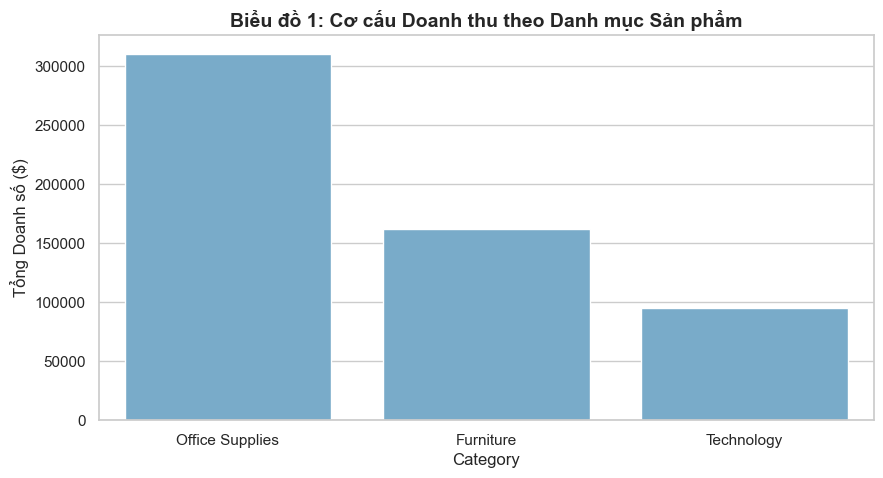

In [5]:
cat_analysis = analyzer.analyze_sales_by_dimension('Category')
display(cat_analysis)

# Trực quan hóa Biểu đồ 1: Doanh số & Lợi nhuận theo Danh mục
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(data=cat_analysis, x='Category', y='Total_Sales', ax=ax1, color=sns.color_palette('Blues_r', n_colors=1)[0])
ax1.set_title('Biểu đồ 1: Cơ cấu Doanh thu theo Danh mục Sản phẩm', fontsize=14, fontweight='bold')
ax1.set_ylabel('Tổng Doanh số ($)', fontsize=12)
plt.show()

**Diễn giải kết quả:**
- Biểu đồ trên cho thấy cơ cấu đóng góp doanh thu của các ngành hàng (Furniture, Office Supplies, Technology).
- Các mặt hàng Thiết bị công nghệ (Technology) và Đồ gỗ nội thất (Furniture) thường có đơn giá cao mang lại doanh số lớn, trong khi Văn phòng phẩm (Office Supplies) duy trì số lượng đơn hàng ổn định.

--- 
## 4. CÂU HỎI PHÂN TÍCH 2: TOP SẢN PHẨM VÀ TOP KHÁCH HÀNG MANG LẠI GIÁ TRỊ CAO NHẤT
**Mục tiêu:** Xác định Top 10 sản phẩm bán chạy nhất và Top 10 khách hàng VIP mang lại doanh thu lớn nhất.

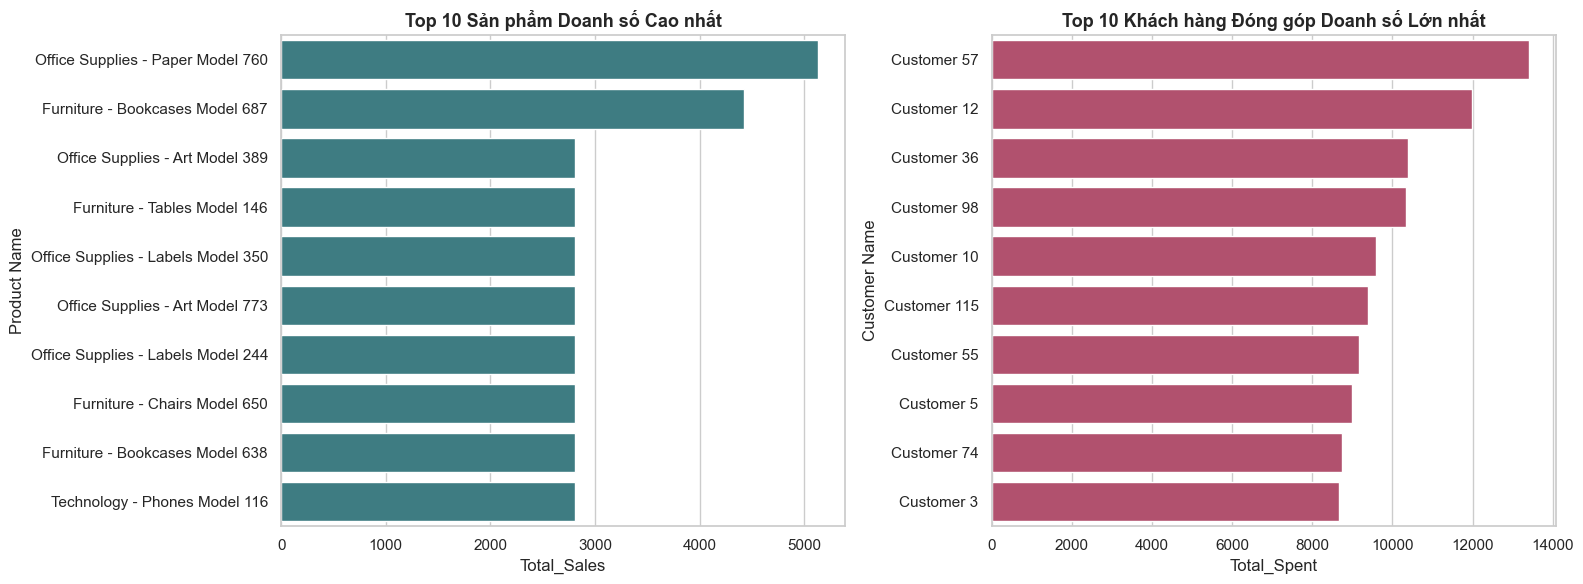

In [6]:
top_prods, top_custs = analyzer.get_top_performers(top_n=10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 2A: Top 10 Sản phẩm
sns.barplot(data=top_prods, y='Product Name', x='Total_Sales', ax=axes[0], color=sns.color_palette('crest', n_colors=1)[0])
axes[0].set_title('Top 10 Sản phẩm Doanh số Cao nhất', fontsize=13, fontweight='bold')

# Biểu đồ 2B: Top 10 Khách hàng
sns.barplot(data=top_custs, y='Customer Name', x='Total_Spent', ax=axes[1], color=sns.color_palette('flare', n_colors=1)[0])
axes[1].set_title('Top 10 Khách hàng Đóng góp Doanh số Lớn nhất', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

--- 
## 5. CÂU HỎI PHÂN TÍCH 3: XU HƯỚNG MÙA VỤ & NGÀY TRONG TUẦN
**Mục tiêu:** Tìm hiểu sự biến động của doanh số theo các tháng trong năm và các ngày trong tuần.

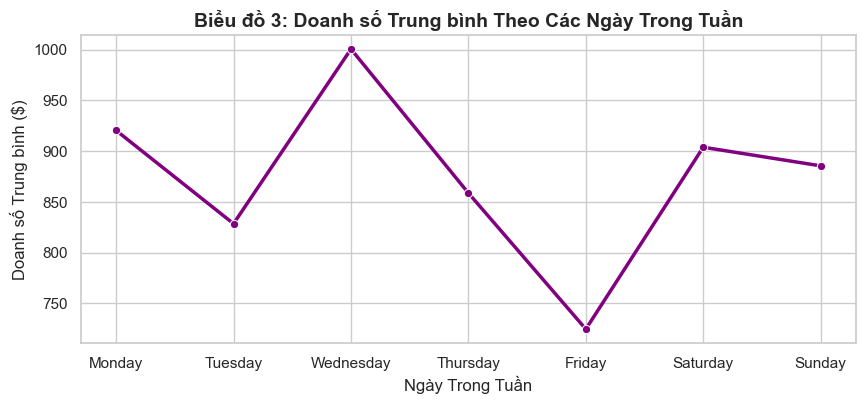

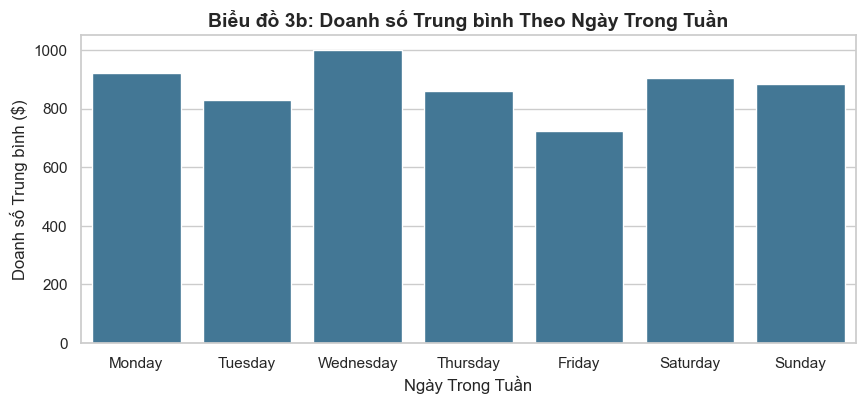

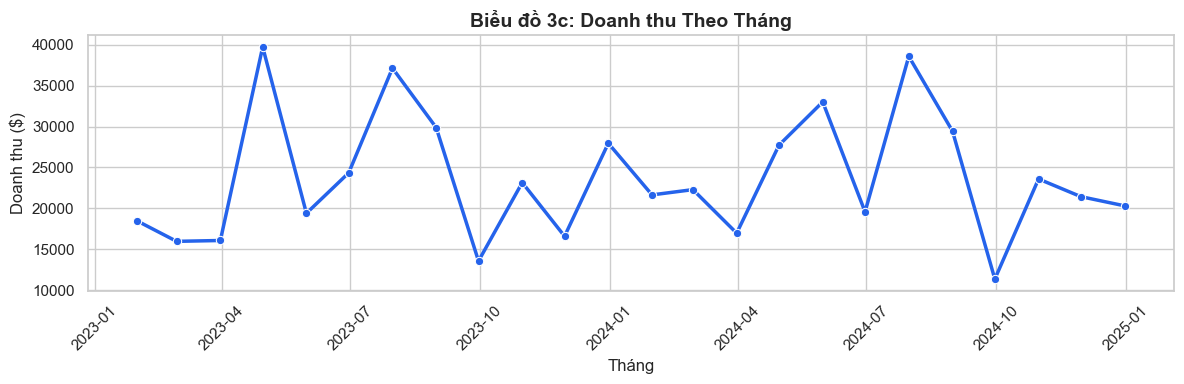

In [7]:
seasonality, _ = analyzer.analyze_seasonality_and_discount()

plt.figure(figsize=(10, 4))
sns.lineplot(data=seasonality, x=seasonality.index, y='Avg_Sales', marker='o', color='purple', linewidth=2.5)
plt.title('Biểu đồ 3: Doanh số Trung bình Theo Các Ngày Trong Tuần', fontsize=14, fontweight='bold')
plt.ylabel('Doanh số Trung bình ($)')
plt.xlabel('Ngày Trong Tuần')
plt.show()

seasonality_reset = seasonality.reset_index().rename(columns={'index': 'DayOfWeek'})
plt.figure(figsize=(10, 4))
sns.barplot(
    data=seasonality_reset,
    x='DayOfWeek',
    y='Avg_Sales',
    order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    color=sns.color_palette('mako', n_colors=1)[0]
)
plt.title('Biểu đồ 3b: Doanh số Trung bình Theo Ngày Trong Tuần', fontsize=14, fontweight='bold')
plt.xlabel('Ngày Trong Tuần')
plt.ylabel('Doanh số Trung bình ($)')
plt.show()

# Thêm biểu đồ doanh thu theo tháng cho yêu cầu DT04
monthly_sales = analyzer.get_monthly_sales()
monthly_sales['Order Date'] = pd.to_datetime(monthly_sales['Order Date'])

plt.figure(figsize=(12, 4))
sns.lineplot(data=monthly_sales, x='Order Date', y='Sales', marker='o', color='#2563eb', linewidth=2.5)
plt.title('Biểu đồ 3c: Doanh thu Theo Tháng', fontsize=14, fontweight='bold')
plt.xlabel('Tháng')
plt.ylabel('Doanh thu ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

--- 
## 6. CÂU HỎI PHÂN TÍCH 4: ĐÁNH GIÁ TÁC ĐỘNG CỦA GIẢM GIÁ (DISCOUNT) ĐẾN LỢI NHUẬN
**Mục tiêu:** Kiểm tra xem chính sách chiết khấu/giảm giá cao có thực sự thúc đẩy lợi nhuận hay gây tổn hại biên lợi nhuận của siêu thị.

,Discount_Band,Avg_Sales,Avg_Profit,Total_Profit,Order_Count
0,0%,984.988230,236.127675,57379.02500,243
1,1-10%,877.278563,146.535089,18609.95625,127
2,11-20%,867.768254,102.052626,18267.42000,179
3,21-30%,695.287736,0.155849,8.26000,53
4,31-50%,525.088542,-52.103333,-2500.96000,48
5,>50%,NaN,NaN,0.00000,0


,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
Column,,,,,,
Sales,302.2300,1306.365,1004.1350,-1203.97250,2812.56750,0
Profit,27.5775,227.670,200.0925,-272.56125,527.80875,0


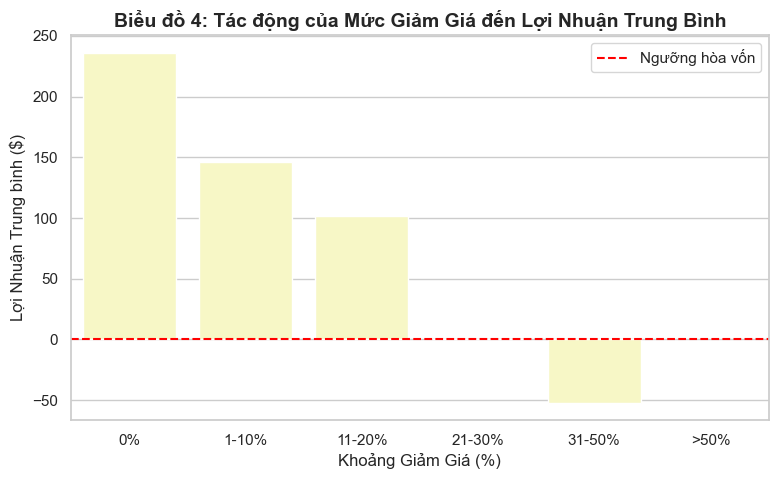

Hệ số tương quan giữa Discount và Profit: -0.577


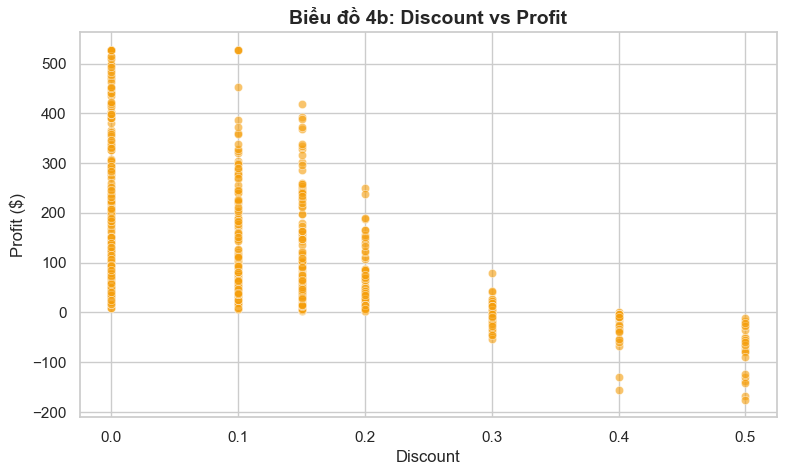

In [8]:
_, discount_impact = analyzer.analyze_seasonality_and_discount()
display(discount_impact)

# Phát hiện ngoại lai bằng IQR cho Sales và Profit
outlier_summary = analyzer.detect_outliers_iqr(columns=['Sales', 'Profit'])
display(outlier_summary)

plt.figure(figsize=(9, 5))
sns.barplot(data=discount_impact, x='Discount_Band', y='Avg_Profit', color=sns.color_palette('Spectral', n_colors=1)[0])
plt.axhline(0, color='red', linestyle='--', label='Ngưỡng hòa vốn')
plt.title('Biểu đồ 4: Tác động của Mức Giảm Giá đến Lợi Nhuận Trung Bình', fontsize=14, fontweight='bold')
plt.xlabel('Khoảng Giảm Giá (%)')
plt.ylabel('Lợi Nhuận Trung bình ($)')
plt.legend()
plt.show()

corr = df_clean[['Discount', 'Profit']].corr().loc['Discount', 'Profit']
print(f"Hệ số tương quan giữa Discount và Profit: {corr:.3f}")

plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_clean, x='Discount', y='Profit', alpha=0.6, color='#F59E0B')
plt.title('Biểu đồ 4b: Discount vs Profit', fontsize=14, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.show()

**Nhận xét:** Khi mức giảm giá vượt quá 20%, lợi nhuận trung bình bị sụt giảm mạnh hoặc âm (lỗ). Siêu thị cần kiểm soát chặt chẽ chính sách khuyến mãi.

--- 
## 7. CÂU HỎI PHÂN TÍCH 5: PIVOT TABLE ĐA CHIỀU & HEATMAP (CATEGORY X REGION)
**Mục tiêu:** Phân tích giao thoa đa chiều giữa Danh mục sản phẩm và Khu vực địa lý.

Region,East,North,South,West
Category,,,,
Furniture,43791.1575,42293.54,39692.8600,36168.1875
Office Supplies,67539.7375,90072.14,80278.2925,72902.2450
Technology,28452.4900,24777.65,17082.1075,25101.1275


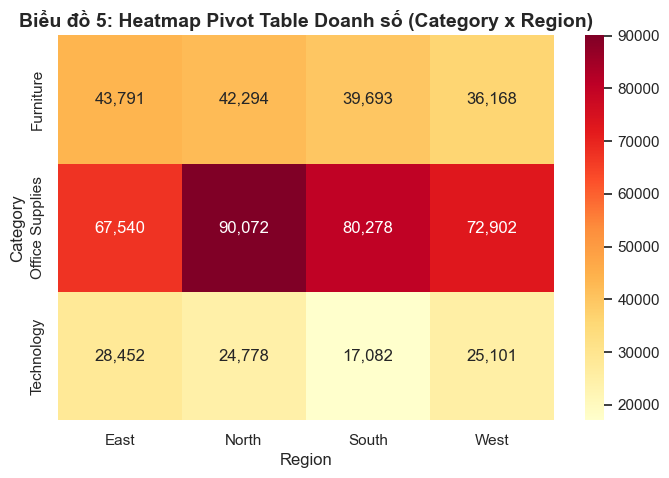

In [9]:
pivot_res = analyzer.create_multidimensional_pivot(index='Category', columns='Region')
display(pivot_res)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_res, annot=True, fmt=",.0f", cmap="YlOrRd")
plt.title('Biểu đồ 5: Heatmap Pivot Table Doanh số (Category x Region)', fontsize=14, fontweight='bold')
plt.show()

--- 
## 8. HƯỚNG PHÁT TRIỂN NÂNG CAO 1: MÔ HÌNH PHÂN KHÚC KHÁCH HÀNG RFM

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Customer_Segment
0,CUST-1000,18,3,2789.7500,4,1,1,411,6,At Risk / Potential
1,CUST-1001,56,5,5901.0000,3,2,3,323,8,Loyal Customers
2,CUST-1002,23,8,8656.4000,4,4,4,444,12,VIP / Champions
3,CUST-1003,367,4,3879.5500,1,1,2,112,4,Lost / Inactive
4,CUST-1004,89,9,8997.2200,3,4,4,344,11,VIP / Champions
5,CUST-1005,96,5,4190.9900,3,2,2,322,7,Loyal Customers
6,CUST-1006,113,3,2271.4000,2,1,1,211,4,Lost / Inactive
7,CUST-1007,139,6,8157.7275,2,3,4,234,9,Loyal Customers
8,CUST-1008,73,6,6601.7875,3,3,3,333,9,Loyal Customers
9,CUST-1009,125,8,9585.9100,2,4,4,244,10,VIP / Champions


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5800\1575871048.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm_table, x='Customer_Segment', palette='Set2')


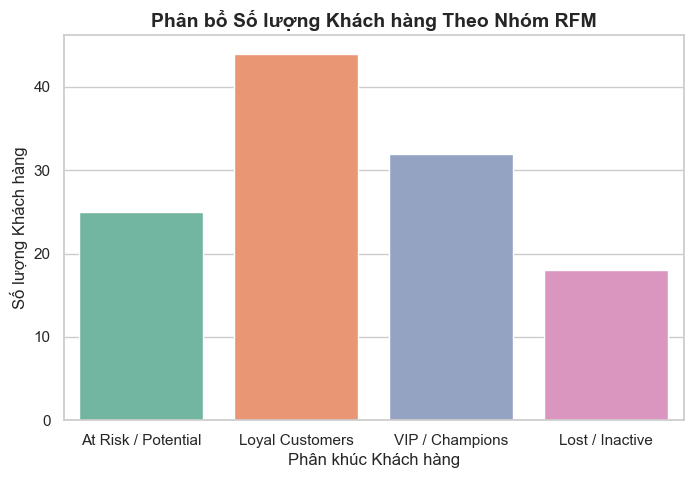

In [10]:
rfm_table = analyzer.calculate_rfm()
display(rfm_table.head(10))

# Phân bổ nhóm khách hàng
plt.figure(figsize=(8, 5))
sns.countplot(data=rfm_table, x='Customer_Segment', palette='Set2')
plt.title('Phân bổ Số lượng Khách hàng Theo Nhóm RFM', fontsize=14, fontweight='bold')
plt.xlabel('Phân khúc Khách hàng')
plt.ylabel('Số lượng Khách hàng')
plt.show()

--- 
## 9. HƯỚNG PHÁT TRIỂN NÂNG CAO 2: PHÂN TÍCH GIỎ HÀNG (MARKET BASKET ANALYSIS)

,Product 1,Product 2,Co_Occurrence_Count
0,Binders,Labels,7
1,Binders,Bookcases,7
2,Storage,Tables,7
3,Art,Storage,6
4,Bookcases,Labels,6
5,Furnishings,Storage,6
6,Accessories,Paper,6
7,Bookcases,Paper,6
8,Binders,Furnishings,5
9,Labels,Storage,5


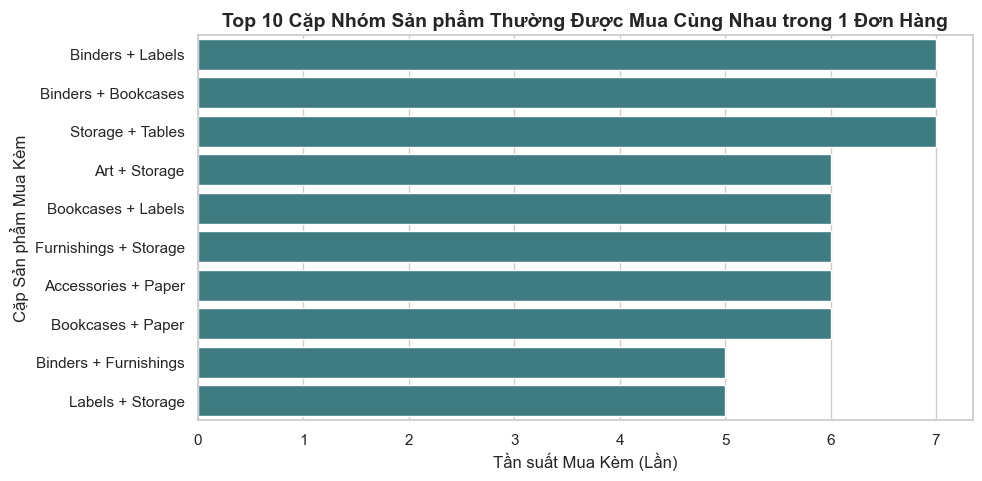

In [11]:
basket_pairs = analyzer.market_basket_analysis(top_pairs=10)
display(basket_pairs)

plt.figure(figsize=(10, 5))
sns.barplot(data=basket_pairs, y=basket_pairs['Product 1'] + ' + ' + basket_pairs['Product 2'], x='Co_Occurrence_Count', color=sns.color_palette('crest', n_colors=1)[0])
plt.title('Top 10 Cặp Nhóm Sản phẩm Thường Được Mua Cùng Nhau trong 1 Đơn Hàng', fontsize=14, fontweight='bold')
plt.xlabel('Tần suất Mua Kèm (Lần)')
plt.ylabel('Cặp Sản phẩm Mua Kèm')
plt.show()

--- 
## 10. KẾT LUẬN VÀ KIẾN NGHỊ
1. **Tối ưu hóa sản phẩm:** Tập trung nguồn lực kinh doanh vào ngành hàng Công nghệ và Đồ gỗ mang lại lợi nhuận cao.
2. **Quản lý chính sách giảm giá:** Giới hạn tỷ lệ chiết khấu tối đa dưới 20% để không ảnh hưởng xấu đến lợi nhuận ròng.
3. **Chiến lược Marketing RFM:** Triển khai chương trình chăm sóc đặc biệt cho nhóm `VIP / Champions` và chương trình kích cầu thu hút lại nhóm `At Risk / Potential`.
4. **Cross-selling:** Sử dụng kết quả phân tích giỏ hàng để thiết kế các gói combo bán kèm nhằm gia tăng giá trị trung bình trên mỗi đơn hàng.